<a href="https://colab.research.google.com/github/WNderitu/data_science_capstone_project/blob/main/malaria_parasite_patching_yolov8small.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plasmodium Vivax (malaria) parasite detector and counter**

## **Notebook 2: YOLO Image Patching & Training**
This notebook patches 1600x1200 images into 512x512 tiles, adjusts YOLO labels, and trains YOLOv8s.
The YOLOv8 small model variant goves a good balance of speed and accuracy; recommended for initial fine-tuning.

In [1]:
from google.colab import drive

# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Mounted at /content/drive
Google Drive mounted successfully!


In [2]:
!pip install ultralytics opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.2 MB/s eta 0:00:00


## **1.1 Installing & Importing Required Libraries**

In [3]:
from ultralytics import YOLO #
import os, cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
import pandas as pd
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##**1.2 Image Augmentations using patching**

In [ ]:
# Base dataset path
BASE = "/content/drive/MyDrive/malaria_dataset_4/malaria/malaria"

# Input
IMG_BASE = f"{BASE}/images"
LBL_BASE = f"{BASE}/labels"

# Output
OUT_BASE = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched"
OUT_IMG = f"{OUT_BASE}/images"
OUT_LBL = f"{OUT_BASE}/labels"

PATCH = 512
W, H = 1600, 1200   # Image resolution

# ✅ Define the splits
splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{OUT_IMG}/{split}", exist_ok=True)
    os.makedirs(f"{OUT_LBL}/{split}", exist_ok=True)

def read_labels(path):
    if not os.path.exists(path):
        return []
    with open(path,'r') as f:
        return [list(map(float,line.split())) for line in f]

for split in splits:
    img_dir = f"{IMG_BASE}/{split}"
    lbl_dir = f"{LBL_BASE}/{split}"

    print(f"🔄 Processing {split}...")

    for img_file in os.listdir(img_dir):
        if not img_file.lower().endswith((".jpg",".png",".jpeg")):
            continue

        img_path = os.path.join(img_dir, img_file)
        lbl_path = os.path.join(lbl_dir, img_file.rsplit('.',1)[0] + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        labels = read_labels(lbl_path)

        for y0 in range(0, H, PATCH):
            for x0 in range(0, W, PATCH):
                if y0+PATCH > H or x0+PATCH > W:
                    continue

                patch = img[y0:y0+PATCH, x0:x0+PATCH]
                out_name = f"{img_file.rsplit('.',1)[0]}_{y0}_{x0}.jpg"

                cv2.imwrite(f"{OUT_IMG}/{split}/{out_name}", patch)

                new_boxes = []
                for cls, xc, yc, w, h in labels:
                    xc_pixel = xc * W
                    yc_pixel = yc * H
                    w_pixel  = w  * W
                    h_pixel  = h  * H

                    if x0 <= xc_pixel <= x0+PATCH and y0 <= yc_pixel <= y0+PATCH:
                        new_x = (xc_pixel - x0) / PATCH
                        new_y = (yc_pixel - y0) / PATCH
                        new_w = w_pixel / PATCH
                        new_h = h_pixel / PATCH
                        new_boxes.append([cls,new_x,new_y,new_w,new_h])

                if len(new_boxes) > 0:
                    with open(f"{OUT_LBL}/{split}/{out_name.replace('.jpg','.txt')}", "w") as f:
                        for b in new_boxes:
                            f.write(" ".join(f"{v:.6f}" for v in b) + "\n")

print("✅ Patching Complete — Split Integrity Preserved!")

🔄 Processing train...
🔄 Processing val...
🔄 Processing test...
✅ Patching Complete — Split Integrity Preserved!


### **1.2.1 Check number of images after patching**

In [4]:
# Define the output image directories for each split
OUT_IMG = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images"
splits = ["train", "val", "test"]

print("Number of images per split after patching:")

for split in splits:
    split_img_dir = f"{OUT_IMG}/{split}"
    if os.path.exists(split_img_dir):
        # List files in the directory and count them
        num_images = len([f for f in os.listdir(split_img_dir) if os.path.isfile(os.path.join(split_img_dir, f))])
        print(f"{split.capitalize()}: {num_images}")
    else:
        print(f"{split.capitalize()}: Directory not found at {split_img_dir}")

Number of images per split after patching:
Train: 1800
Val: 516
Test: 720


### **1.2.2 View images after patching**

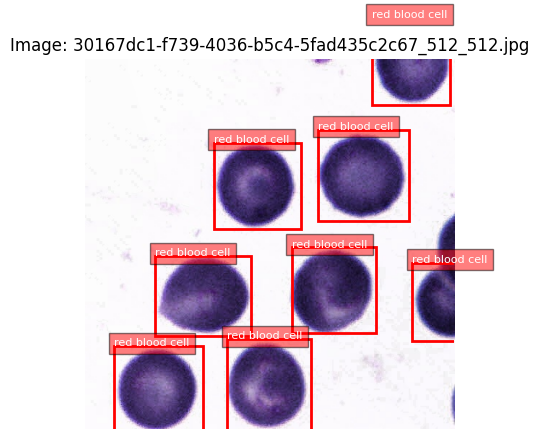

Labels for 30167dc1-f739-4036-b5c4-5fad435c2c67_512_512.jpg:
[0.0, 0.753906, 0.313477, 0.246094, 0.248046]
[0.0, 0.318359, 0.638673, 0.257812, 0.214845]
[0.0, 0.988281, 0.655273, 0.207031, 0.21289]
[0.0, 0.880859, 0.004883, 0.210938, 0.236327]
[0.0, 0.198241, 0.893555, 0.240234, 0.236327]
[0.0, 0.67285, 0.623047, 0.228516, 0.230468]
[0.0, 0.498047, 0.878907, 0.226562, 0.246094]
[0.0, 0.465819, 0.34082, 0.236328, 0.232423]


In [7]:
# Define paths
OUT_IMG = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images"
OUT_LBL = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels"
split = "train"  # Choose a split to visualize from

img_dir = f"{OUT_IMG}/{split}"
lbl_dir = f"{OUT_LBL}/{split}"

# Get a list of all image files in the chosen split
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

if not image_files:
    print(f"No images found in {img_dir}")
else:
    # Select a random image file
    img_file = random.choice(image_files)
    img_path = os.path.join(img_dir, img_file)
    lbl_path = os.path.join(lbl_dir, img_file.rsplit('.', 1)[0] + ".txt")

    # Read the image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib

    # Read the labels
    labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                labels.append(list(map(float, line.split())))

    # Get image dimensions
    h, w, _ = img.shape

    # Create a figure and axes
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    # Add bounding boxes to the image
    for label in labels:
        cls, xc, yc, bw, bh = label
        # Convert YOLO format (center_x, center_y, width, height) to
        # matplotlib format (x, y, width, height) where x, y is top-left corner
        x = (xc - bw/2) * w
        y = (yc - bh/2) * h
        width = bw * w
        height = bh * h

        # Create a Rectangle patch
        rect = patches.Rectangle((x, y), width, height,
                                 linewidth=2, edgecolor='r', facecolor='none')

        # Add the patch to the Axes
        ax.add_patch(rect)

        # Optionally add class label text
        class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
        if int(cls) < len(class_names):
            class_name = class_names[int(cls)]
            plt.text(x, y, class_name, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))


    plt.title(f"Image: {img_file}")
    plt.axis('off') # Hide axes
    plt.show()

    print(f"Labels for {img_file}:")
    if labels:
        for label in labels:
            print(label)
    else:
        print("No labels found for this image.")

### **1.2.3 Check imbalance after patching**

In [8]:
class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

print("\nClass Imbalance Check Across Splits:")

for split in splits:
    print(f"\n{split.capitalize()} Set Class Counts:")
    split_label_dir = f"{OUT_LBL}/{split}"
    split_class_counts = {i: 0 for i in range(num_classes)}

    for label_file in os.listdir(split_label_dir):
        if label_file.endswith(".txt"):
            label_path = os.path.join(split_label_dir, label_file)
            with open(label_path, 'r') as f:
                for line in f:
                    # Split the line and take the first element as the class ID
                    # Convert it to an integer
                    class_id = int(float(line.split()[0]))
                    split_class_counts[class_id] += 1

    for cls_id, count in split_class_counts.items():
        print(f"Class {cls_id} ({class_names[cls_id]}): {count}")


Class Imbalance Check Across Splits:

Train Set Class Counts:
Class 0 (red blood cell): 16416
Class 1 (trophozoite): 414
Class 2 (ring): 101
Class 3 (schizont): 40
Class 4 (gametocyte): 41
Class 5 (leukocyte): 23
Class 6 (difficult): 100

Val Set Class Counts:
Class 0 (red blood cell): 5154
Class 1 (trophozoite): 96
Class 2 (ring): 26
Class 3 (schizont): 9
Class 4 (gametocyte): 9
Class 5 (leukocyte): 5
Class 6 (difficult): 36

Test Set Class Counts:
Class 0 (red blood cell): 4938
Class 1 (trophozoite): 106
Class 2 (ring): 157
Class 3 (schizont): 11
Class 4 (gametocyte): 11
Class 5 (leukocyte): 0
Class 6 (difficult): 5



Class Imbalance Visualization Across Splits:

Train Set Class Distribution:


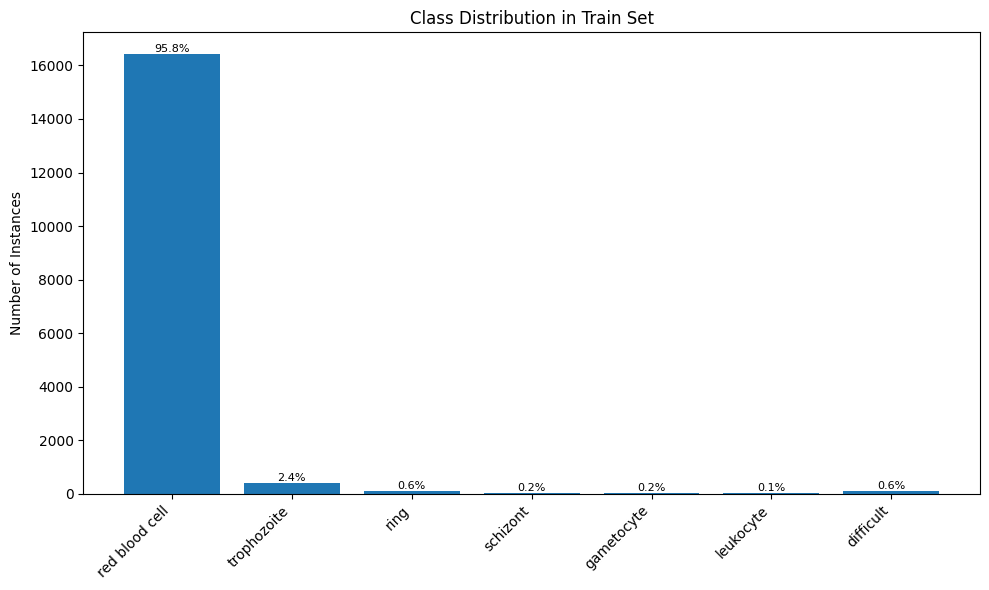

Class 0 (red blood cell): 16416 (95.8%)
Class 1 (trophozoite): 414 (2.4%)
Class 2 (ring): 101 (0.6%)
Class 3 (schizont): 40 (0.2%)
Class 4 (gametocyte): 41 (0.2%)
Class 5 (leukocyte): 23 (0.1%)
Class 6 (difficult): 100 (0.6%)

Val Set Class Distribution:


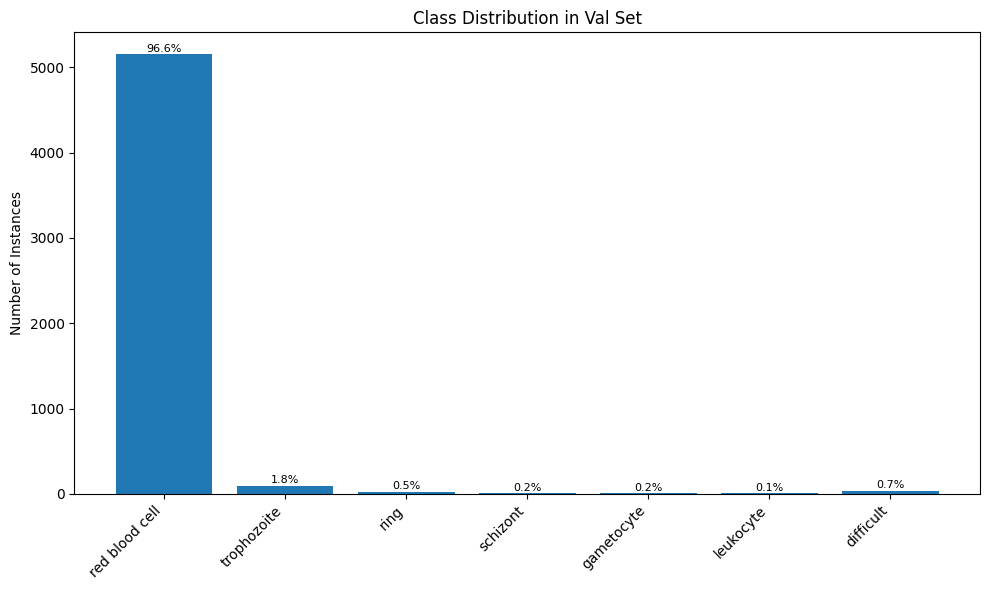

Class 0 (red blood cell): 5154 (96.6%)
Class 1 (trophozoite): 96 (1.8%)
Class 2 (ring): 26 (0.5%)
Class 3 (schizont): 9 (0.2%)
Class 4 (gametocyte): 9 (0.2%)
Class 5 (leukocyte): 5 (0.1%)
Class 6 (difficult): 36 (0.7%)

Test Set Class Distribution:


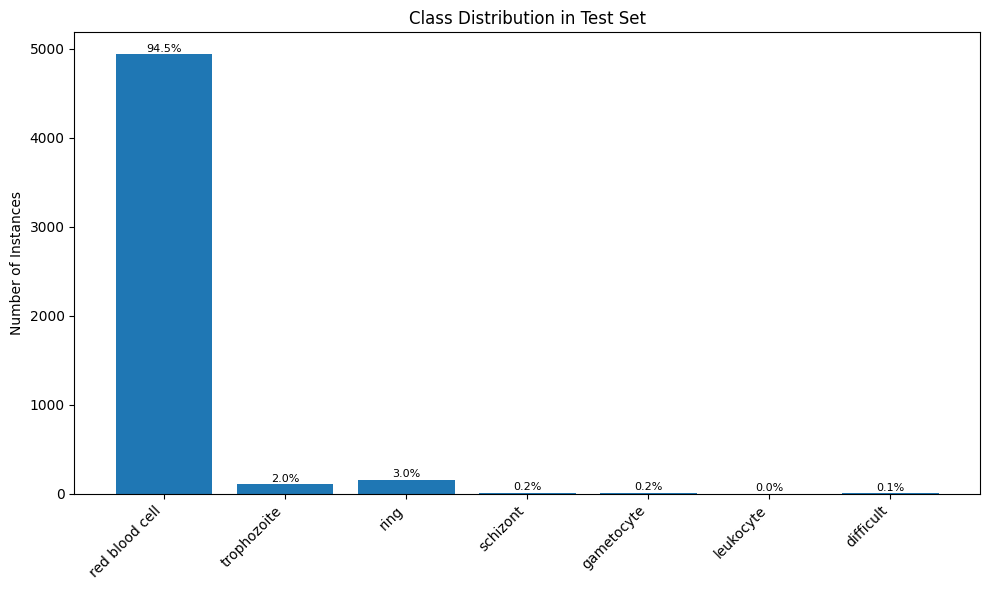

Class 0 (red blood cell): 4938 (94.5%)
Class 1 (trophozoite): 106 (2.0%)
Class 2 (ring): 157 (3.0%)
Class 3 (schizont): 11 (0.2%)
Class 4 (gametocyte): 11 (0.2%)
Class 5 (leukocyte): 0 (0.0%)
Class 6 (difficult): 5 (0.1%)


In [9]:
# visualize class imbalance across splits
# Assuming split_class_counts and splits are available from the previous cell

class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

print("\nClass Imbalance Visualization Across Splits:")

for split in splits:
    print(f"\n{split.capitalize()} Set Class Distribution:")
    split_label_dir = f"{OUT_LBL}/{split}"
    split_class_counts = {i: 0 for i in range(num_classes)}

    # Re-calculate counts in case the previous cell wasn't run or output is not directly accessible
    if os.path.exists(split_label_dir):
        for label_file in os.listdir(split_label_dir):
            if label_file.endswith(".txt"):
                label_path = os.path.join(split_label_dir, label_file)
                with open(label_path, 'r') as f:
                    for line in f:
                        try:
                            class_id = int(float(line.split()[0]))
                            if class_id < num_classes:
                                split_class_counts[class_id] += 1
                        except (ValueError, IndexError):
                            print(f"Skipping invalid line in {label_file}: {line.strip()}")
    else:
        print(f"Directory not found for {split}: {split_label_dir}")
        continue


    total_instances = sum(split_class_counts.values())
    if total_instances == 0:
        print(f"No instances found in the {split} set.")
        continue

    class_counts = list(split_class_counts.values())
    class_percentages = [(count / total_instances) * 100 for count in class_counts]

    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(class_names, class_counts)

    # Add percentages on top of bars
    for bar, percentage in zip(bars, class_percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{percentage:.1f}%',
                ha='center', va='bottom', fontsize=8)

    plt.ylabel("Number of Instances")
    plt.title(f"Class Distribution in {split.capitalize()} Set")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Print counts as well
    for cls_id, count in split_class_counts.items():
        print(f"Class {cls_id} ({class_names[cls_id]}): {count} ({class_percentages[cls_id]:.1f}%)")

### **1.2.4 Calculate class weights**

In [11]:
# Assuming OUT_LBL, num_classes, and class_names are defined from previous cells

train_labels_path = os.path.join(OUT_LBL, "train")

class_counts = np.zeros(num_classes, dtype=int)

if os.path.exists(train_labels_path):
    for file in os.listdir(train_labels_path):
        if file.endswith(".txt"):
            with open(os.path.join(train_labels_path, file), "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:  # YOLO format: cls, x, y, w, h
                        try:
                            cls = int(float(parts[0]))  # convert float -> int safely
                            if 0 <= cls < num_classes:
                                class_counts[cls] += 1
                            else:
                                print(f"Warning: Class ID {cls} out of range in file {file}")
                        except ValueError:
                            print(f"Warning: Could not parse class ID in line: {line.strip()} in file {file}")
    print("Class sample counts:", class_counts)

    # Compute normalized inverse frequency weights
    # Add a small epsilon to avoid division by zero for classes with zero samples
    class_weights_inv_freq = 1 / (class_counts + 1e-6)
    class_weights_inv_freq = class_weights_inv_freq / class_weights_inv_freq.sum()
    class_weights_inv_freq = class_weights_inv_freq * num_classes

    # Store the calculated weights in the `class_weights_array` variable
    class_weights_array = class_weights_inv_freq.tolist()

    print("\n✅ Normalized Inverse Frequency Class Weights Array (use these):")
    print(class_weights_array)
else:
    print(f"Error: Training labels directory not found at {train_labels_path}")

Class sample counts: [16416   414   101    40    41    23   100]

✅ Normalized Inverse Frequency Class Weights Array (use these):
[0.0037000307919323075, 0.14671426409987082, 0.601383216660174, 1.5184925991392049, 1.481456195185478, 2.640856645356702, 0.6073970487666374]


### **1.2.5 Create YOLO YAML file for patched dataset**

In [28]:
class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

# Define the paths for the train, val and test image and label directories
train_patch_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/train'
val_patch_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/val'
test_patch_dir =  '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test'

class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

# Create the data dictionary for the YAML file
data = {
    'train': train_patch_dir,
    'val': val_patch_dir,
    'test': test_patch_dir,
    'nc':num_classes,  # Number of classes
    'names': class_names # List of class names
}

# Check if class_weights_array is available and add it to the data dictionary
if 'class_weights_array' in locals() and class_weights_array:
    data['cls_weights'] = class_weights_array
    print("✅ Added class weights to the YAML data dictionary.")
else:
    print("⚠️ class_weights_array not found. Class weights will not be added to the YAML unless defined elsewhere.")


# Define the path where the YAML file will be saved in Google Drive
yaml_file_path = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml'

try:
    with open(yaml_file_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False)
    print(f" YOLO data configuration (with potentially added weights) saved at: {yaml_file_path}")
except Exception as e:
    print(f"Error creating YOLO data configuration file: {e}")


✅ Added class weights to the YAML data dictionary.
 YOLO data configuration (with potentially added weights) saved at: /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml


In [29]:
import yaml

yaml_file_path = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml'

try:
    with open(yaml_file_path, 'r') as f:
        yaml_content = yaml.safe_load(f)
    print("--- Content of dataset_patched.yaml ---")
    print(yaml.dump(yaml_content, default_flow_style=False))
    print("---------------------------------------")
except FileNotFoundError:
    print(f"Error: The file {yaml_file_path} was not found.")
except Exception as e:
    print(f"An error occurred while reading the YAML file: {e}")

--- Content of dataset_patched.yaml ---
cls_weights:
- 0.0037000307919323075
- 0.14671426409987082
- 0.601383216660174
- 1.5184925991392049
- 1.481456195185478
- 2.640856645356702
- 0.6073970487666374
names:
- red blood cell
- trophozoite
- ring
- schizont
- gametocyte
- leukocyte
- difficult
nc: 7
test: /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/test
train: /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/train
val: /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/val

---------------------------------------


## **1.3 Train YOLOv8 model**

### **1.3.1 1st run**

In [ ]:
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# --- Step 1: Define paths
yaml_path = '/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml'
save_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results'
run_name = 'malaria_yolov8s_train_1'

# --- Step 2: Initialize YOLO model
model = YOLO("yolov8s.pt")  # load pretrained model (recommended)

# --- Step 3: Handle class weights
if 'class_weights_array' in locals() and class_weights_array is not None:
    print("✅ Class weights detected and will be used.")
    cls_weights_arg = class_weights_array.tolist()  # ensure list format
else:
    print("⚠️ No class weights found. Continuing without class weighting.")
    cls_weights_arg = None

# --- Step 4: Train
results = model.train(
    data=yaml_path,
    epochs=300,
    imgsz=512,
    device=0,
    optimizer='AdamW',
    lr0=0.001,
    amp=True,
    batch = 16,

    # small-object augmentations
    mosaic=0.3,
    copy_paste=0.1,
    mixup=0.0,

    # color + spatial augmentations tuned for microscopy
    hsv_h=0.03,
    hsv_s=0.1,
    hsv_v=0.7,
    translate=0.1,
    flipud=0.5,
    fliplr=0.5,
    degrees=5,
    scale=0.5,
    shear=2,
    perspective=0.0005,

    close_mosaic=10,
    patience=150,
    cls = 3.0,
    project=save_dir,
    name=run_name,
    exist_ok=True,
    verbose=True
)

print("\n✅ Training complete.\n")

# ✅ Confirm class weights used
if cls_weights_arg is not None:
    print("Using class weights:", cls_weights_arg)
else:
    print("❌ No class weights applied.")

⚠️ No class weights found. Continuing without class weighting.
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.1, hsv_v=0.7, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=malaria_yolov8s_train

Interpretation

Final validation metrics indicate a good general performance but highlight class-specific weaknesses, particularly for rare classes.

Overall classes
| Metric    | Value     | Interpretation                           |
| --------- | --------- | ---------------------------------------- |
| Precision | **0.739** | Model avoids false positives fairly well. When the model predicts an object, it's correct approx 74% of the time |
| Recall    | **0.741** | The model finds approx 74% of all actual objects in the validation set.    |
| mAP50     | **0.778** | Good overall detection performance, The model's bounding box localization and classification accuracy is quite good when a loose IoU threshold of 0.5 is used.      |
| mAP50-95  | **0.593** | Expected for tiny medical objects. Accuracy drops when stricter IoU thresholds are considered (average across 0.5 to 0.95). This indicates the model struggles to produce highly precise bounding boxes.     |


Per class performance

| Class              | Support | Precision | Recall   | Notes                                          |
| ------------------ | ------- | --------- | -------- | ---------------------------------------------- |
| **red blood cell** | 5154    | **0.92**  | **0.96** | Very strong, easy class                      |
| **trophozoite**    | 96      | **0.79**  | **0.80** | Good, but room to sharpen stage boundaries   |
| **ring**           | 26      | **0.80**  | **0.65** | Under-detection (recall drop)               |
| **schizont**       | 9       | **0.40**  | **0.61** | Struggling (very small sample count)        |
| **gametocyte**     | 9       | **0.66**  | **0.64** | Reasonable given rarity                      |
| **leukocyte**      | 5       | **1.00**  | **0.99** | Perfect (large and distinct morphologically) |
| **difficult**      | 36      | **0.59**  | **0.53** | Hard class by definition                    |


Overall findings
1. Rarest classes (schizont, gametocyte, difficult) have low recall because:
- They appear in very few examples
- No class weights were applied (confirmed by: No class weights applied.)
- YOLO optimizes toward the dominant class (RBC), which achieves near-perfect accuracy. This is expected without class balancing

Next steps
- Introduce class weights, which will:
  - Increase recall for underrepresented parasite stages
  - Improve parasite stage separation
  - Reduce model bias toward red blood cells


#### **1.3.1.1 Error analysis**

#### Training and validation loss curves

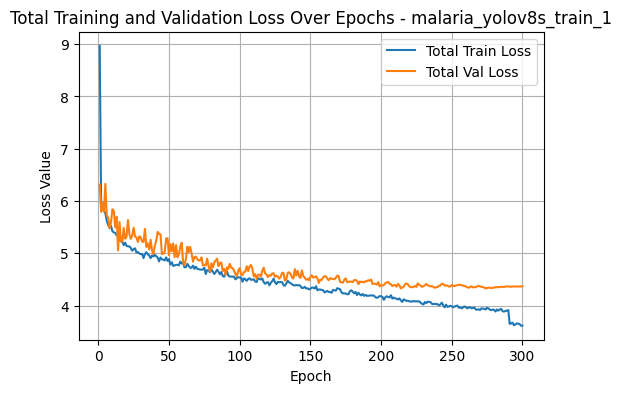


Last 5 epochs' total losses:
     epoch  total_train_loss  total_val_loss
295    296           3.65924         4.36835
296    297           3.65565         4.36483
297    298           3.64815         4.36407
298    299           3.61588         4.36615
299    300           3.61788         4.37093


In [13]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Define the directory where training results were saved
save_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results'
run_name = 'malaria_yolov8s_train_1'

results_dir = os.path.join(save_dir, run_name)
results_csv_path = os.path.join(results_dir, 'results.csv')

# Plot training and validation losses
if os.path.exists(results_csv_path):
    try:
        results_df = pd.read_csv(results_csv_path)
        # Skip the first row if it's not the header
        if results_df.columns[0] != 'epoch':
            results_df = pd.read_csv(results_csv_path, skiprows=1)

        # Identify relevant loss columns
        train_box_loss_col = 'train/box_loss'
        train_cls_loss_col = 'train/cls_loss'
        train_dfl_loss_col = 'train/dfl_loss'
        val_box_loss_col = 'val/box_loss'
        val_cls_loss_col = 'val/cls_loss'
        val_dfl_loss_col = 'val/dfl_loss'

        required_cols = [train_box_loss_col, train_cls_loss_col, train_dfl_loss_col,
                         val_box_loss_col, val_cls_loss_col, val_dfl_loss_col]

        if all(col in results_df.columns for col in required_cols):
            results_df['total_train_loss'] = results_df[train_box_loss_col] + results_df[train_cls_loss_col] + results_df[train_dfl_loss_col]
            results_df['total_val_loss'] = results_df[val_box_loss_col] + results_df[val_cls_loss_col] + results_df[val_dfl_loss_col]

            plt.figure(figsize=(6, 4))
            plt.plot(results_df['epoch'], results_df['total_train_loss'], label='Total Train Loss')
            plt.plot(results_df['epoch'], results_df['total_val_loss'], label='Total Val Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss Value')
            plt.title('Total Training and Validation Loss Over Epochs - malaria_yolov8s_train_1')
            plt.legend()
            plt.grid(True)
            plt.show()

            print("\nLast 5 epochs' total losses:")
            print(results_df[['epoch', 'total_train_loss', 'total_val_loss']].tail())
        else:
            print("Error: Required loss columns not found in results.csv.")
            print("Available columns:", results_df.columns.tolist())

    except Exception as e:
        print(f"Error reading or processing results.csv for loss plots: {e}")
else:
    print(f"Error: results.csv not found at {results_csv_path}. Cannot plot losses.")

#### Overall precision, recall and F1 score over epochs

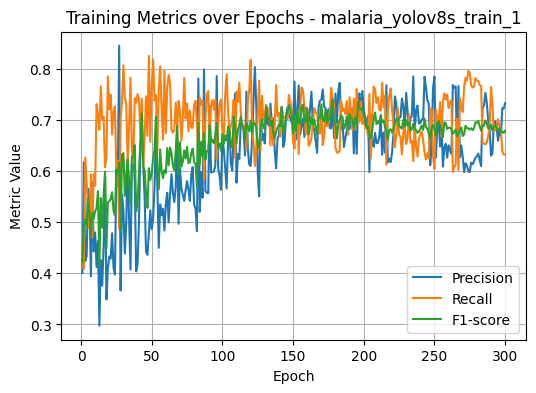


Last 5 epochs metrics:
     epoch  metrics/precision(B)  metrics/recall(B)        f1
295    296               0.68112            0.68768  0.684384
296    297               0.66971            0.68080  0.675209
297    298               0.72337            0.63775  0.677867
298    299               0.72288            0.63255  0.674705
299    300               0.73303            0.63208  0.678822


In [14]:
# Define the correct path to the results.csv file in Google Drive
results_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/results.csv"

# Check if the file exists before trying to read it
if os.path.exists(results_path):
    # Read the CSV file, skipping the first line if it contains non-header info
    try:
        results = pd.read_csv(results_path)
        # Check if the first column is 'epoch' and if not, skip the first row
        if results.columns[0] != 'epoch':
             results = pd.read_csv(results_path, skiprows=1)
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        results = None


    if results is not None and 'metrics/precision(B)' in results.columns and 'metrics/recall(B)' in results.columns:
        # Calculate F1 score
        results['f1'] = 2 * (results['metrics/precision(B)'] * results['metrics/recall(B)']) / (results['metrics/precision(B)'] + results['metrics/recall(B)'])

        # Plotting the metrics
        plt.figure(figsize=(6, 4))
        plt.plot(results['epoch'], results['metrics/precision(B)'], label='Precision')
        plt.plot(results['epoch'], results['metrics/recall(B)'], label='Recall')
        plt.plot(results['epoch'], results['f1'], label='F1-score')
        plt.xlabel('Epoch')
        plt.ylabel('Metric Value')
        plt.title('Training Metrics over Epochs - malaria_yolov8s_train_1')
        plt.legend()
        plt.grid(True)
        plt.show()

        print("\nLast 5 epochs metrics:")
        print(results[['epoch','metrics/precision(B)','metrics/recall(B)','f1']].tail())

    else:
        print(f"Error: Required metric columns not found in {results_path} or file could not be read.")
        if results is not None:
             print("Available columns:", results.columns.tolist())


else:
    print(f"Error: results.csv not found at {results_path}")
    print("Please ensure the training completed successfully and the path is correct.")

- Total Train Loss drops consistently throughout the 300 epochs, ending around 3.6
- Total Val Loss drops sharply initially but flattens out and diverges from the training loss after approx 150 epochs, stabilizing around 4.3
- The widening gap between the 2 loss curves is a clear indication of overfitting. The model is still improving its fit on the training data but has stopped generalizing to the validation data. Training past 200 epochs provided minimal benefit and exacerbated overfitting.

#### Losses & Metrics over epochs

Attempting to display plot from: /content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1

Displaying: results.png


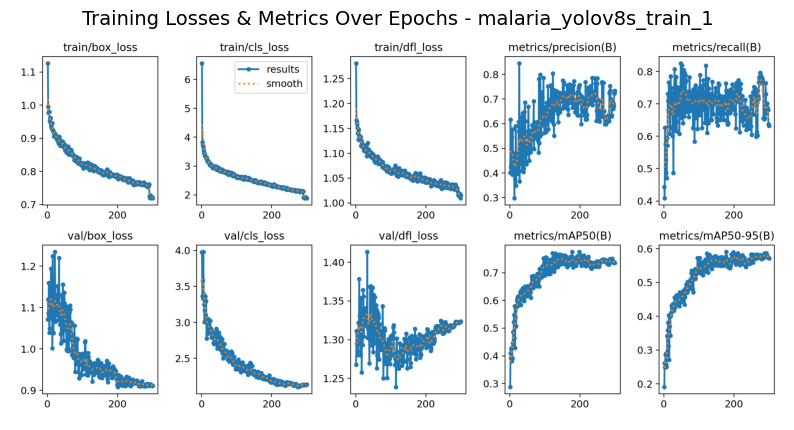

In [15]:
# visualize evaluation metrics with plots
import matplotlib.pyplot as plt
import os

# Define the directory where training results were saved
save_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results'
run_name = 'malaria_yolov8s_train_1'

results_dir = os.path.join(save_dir, run_name)

print(f"Attempting to display plot from: {results_dir}")

# Plot results.png
plot_path = os.path.join(results_dir, 'results.png')
if os.path.exists(plot_path):
    print(f"\nDisplaying: results.png")
    try:
        img = plt.imread(plot_path)
        plt.figure(figsize=(10,8))
        plt.imshow(img)
        plt.title('Training Losses & Metrics Over Epochs - malaria_yolov8s_train_1', fontsize=14)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error displaying results.png: {e}")
else:
    print(f"Plot file not found: results.png")

- val/box_loss - (Localization): Highly volatile in the first 100 epochs, but ultimately stabilizes and drops. This is a good sign, showing the model learned to localize objects.
- val/cls_loss - (Classification): Drops well but shows a clear flattening after approx 200 epochs.
- val/dfl_loss - (Distribution Focal Loss): Shows high instability throughout, which relates to the model's confidence in its bounding box distribution prediction. This volatility likely contributes to the lower mAP50-95.

- Extreme high volatility in Precision and Recall persists. This is likely due to high learning rate combined with AdamW optimizer and aggressive augmentations. The fact that metrics/precision(B) and metrics/recall(B) are relatively flat after approx 150 epochs confirms that the average performance has plateaued, despite the large fluctuations.

#### Confusion matrix

Attempting to display plot from: /content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1

Displaying: confusion_matrix.png


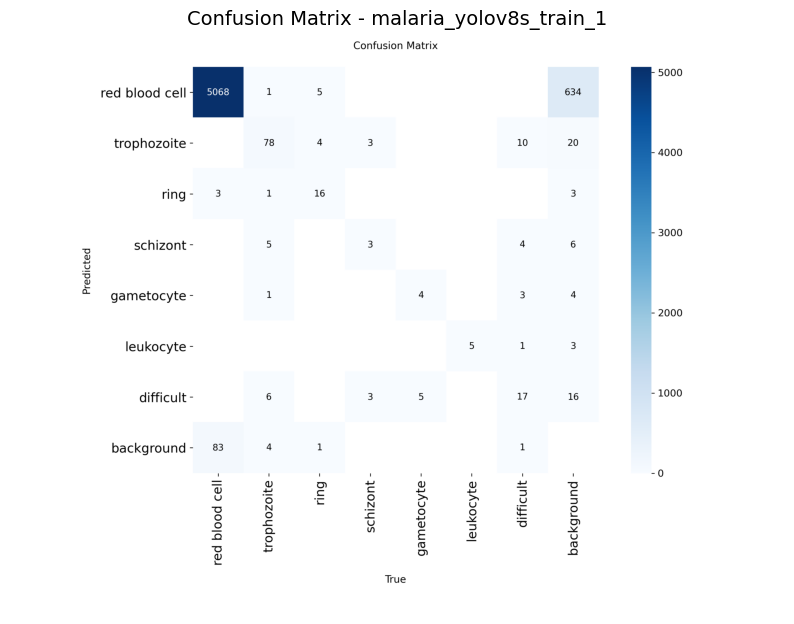

In [17]:
import matplotlib.pyplot as plt
import os

# Define the directory where training results were saved
save_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results'
run_name = 'malaria_yolov8s_train_1'
results_dir = os.path.join(save_dir, run_name)

print(f"Attempting to display plot from: {results_dir}")

# Plot confusion_matrix.png
plot_path = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(plot_path):
    print(f"\nDisplaying: confusion_matrix.png")
    try:
        img = plt.imread(plot_path)
        plt.figure(figsize=(10,8))
        plt.imshow(img)
        plt.title('Confusion Matrix - malaria_yolov8s_train_1', fontsize=14)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error displaying confusion_matrix.png: {e}")
else:
    print(f"Plot file not found: confusion_matrix.png")

- Red blood cell - Few confusions. Excellent Recall.
- Trophozoites - 6 objects confused with difficult,5 confused with schizont, 1 with gaemtocyte, ring and red blood cell.
- Ring - 5 confused with red blood cell ,4 confused with trophozoite
- Schizont - 3 confused with trophozoite, 3 confused with difficult.
- gametocyte - 5 confused with difficult.
- Leuokocyte - no confusion with other classes
- Difficult - 16 confused with background, 10 with trophozoite, 4 schizont, 3 gametocyte, 1 leukocyte.


Recommendations for improving training:
1. Stop Overfitting / Reduce Variance by:
- Adjusting hyperparameters:
  - Reduce learning rate to 0.0001 for the AdamW optimizer
  - Reduce the harshness of augmentations like scale and shear.
- Early Stopping: Set patience to a much lower value e.g., 50 to stop training earlier, as the loss and mAP plateaued around Epoch 200

2. Improve Bounding Box Precision mAP50-95 by:
- Changing box loss (localization Loss:
3. Address Class Imbalance (Rare Classes) by:
- Augmentation Focus: Focus augmentations on the rare parasite classes to synthesize more training examples
- Loss Weighting: Ensure class_weights_array is properly implemented and significantly weights the rare classes (trophozoite, ring, schizont, gametocyte) to force the model to prioritize learning them

### **1.3.2 2nd run**

##### **Recalculate class weights**

In [ ]:
train_labels = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/train"

num_classes = 7
class_counts = np.zeros(num_classes, dtype=int)

for file in os.listdir(train_labels):
    if file.endswith(".txt"):
        with open(os.path.join(train_labels, file), "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:  # YOLO format: cls, x, y, w, h
                    cls = int(float(parts[0]))  # ✅ convert float → int safely
                    class_counts[cls] += 1

print("Class sample counts:", class_counts)

# Compute normalized inverse frequency weights
class_weights = 1 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights * num_classes

print("\n✅ Normalized Class Weights Array (use these):")
print(class_weights.tolist())


Class sample counts: [16416   414   101    40    41    23   100]

✅ Normalized Class Weights Array (use these):
[0.0037000307919323075, 0.14671426409987082, 0.601383216660174, 1.5184925991392049, 1.481456195185478, 2.640856645356702, 0.6073970487666374]


##### **Run fine tuning of model**

In [ ]:
from ultralytics import YOLO
import torch
# from ultralytics.utils.callbacks import Callbacks

# 1) Load model
model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt")

# 2) Class weights (same as before)
class_weights = torch.tensor(
    [0.00370003, 0.14671426, 0.60138322, 1.51849260, 1.48145620, 2.64085665, 0.60739705],
    dtype=torch.float32,
    device="cuda"
)

# 3) Apply class weights ONCE when loss first appears
class_weights_applied = False

def apply_class_weights(trainer):
    global class_weights_applied
    if not class_weights_applied and trainer.loss is not None:
        trainer.loss.class_weights = class_weights
        class_weights_applied = True
        print("\n✅ Class weights successfully applied to YOLO loss.\n")

model.add_callback("on_train_batch_start", apply_class_weights)

# 4) Print F1 table at the end of training
def log_f1(trainer):
    if trainer.epoch == trainer.epochs - 1:
        print("\n📊 Running final validation for per-class F1:\n")
        # Call val through YOLO API wrapper, not raw model
        trainer.model.model.val()

model.add_callback("on_fit_epoch_end", log_f1)

# --- Resume fine-tuning with weights ---
# will train a short fine-tuning run, NOT full 300 epochs again from the best model
model.train(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    epochs=50,                 # short fine-tune, not long training
    imgsz=512,
    lr0=0.0005,                 # reduce learning rate for fine-tuning
    optimizer="AdamW",
    amp=True,
    batch = 16,

    # small-object augmentations
    mosaic=0.1,
    copy_paste=0.1,
    mixup=0.0,

    # color + spatial augmentations tuned for microscopy
    hsv_h=0.03,
    hsv_s=0.1,
    hsv_v=0.7,
    translate=0.1,
    flipud=0.5,
    fliplr=0.5,
    degrees=5,
    scale=0.5,
    shear=2,
    perspective=0.0005,

    close_mosaic=10,
    cls = 3.0,

    exist_ok=True,
    verbose=True,
    patience=30,
    device=0,
    project="/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results",
    name="malaria_yolov8s_train_1_rebalanced"
)

print("\n✅ Training complete.\n")

print("Check the training logs above to confirm if class weights were applied.")

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.1, hsv_v=0.7, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt, momentum=0.937, mosaic=0.3, multi_sc

AttributeError: 'Sequential' object has no attribute 'val'

Since the execution failed at this bit of the code:
---> Print F1 table at the end of training and training was complete, i will run validation separately to avoid running the train again to get the model performance metrics.

##### **Evaluation of fine tuned model**

In [ ]:
from ultralytics import YOLO

# Load your model (best weights from the rebalanced training)
model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1_rebalanced/weights/best.pt")

# ✅ Corrected callback
def log_f1(trainer):
    if trainer.epoch == trainer.epochs - 1:
        print("\n📊 Running final validation for per-class F1:\n")
        trainer.model.val(
            data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
            split="val"
        )

# Re-register callback (clean replace)
model.callbacks.clear()   # remove old broken callback
model.add_callback("on_fit_epoch_end", log_f1)

print("✅ Callback re-registered successfully. Now running standalone validation...\n")

# ✅ Run final validation only (no training)
metrics = model.val(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    split="val"
)

print("\n✅ Validation complete.")

✅ Callback re-registered successfully. Now running standalone validation...

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.2 ms, read: 0.1±0.0 MB/s, size: 47.1 KB)
val: Scanning /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/val.cache... 514 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 516/516 211.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 0.1it/s 5:13
                   all        516       5335      0.803       0.61      0.774      0.594
        red blood cell        514       5154      0.962      0.908      0.984      0.765
           trophozoite         82         96      0.783      0.715      0.838       0.61
                  ring         25         26      0.745      0.654       0.72      0.547
            

Comparison of the 1st model and fine tune model


| Class                  | Metric    | **Before (Original)** | **After (Rebalanced)** | Change          | Interpretation                                             |
| ---------------------- | --------- | --------------------- | ---------------------- | --------------- | ---------------------------------------------------------- |
| **All Classes (mean)** | Precision | 0.739                 | **0.803**              | ⬆ **Improved** | Model is more confident & less false positives             |
|                        | Recall    | **0.741**             | 0.610                  | ⬇ Decreased    | Model is now **more selective** The model is missing a lot more actual objects (more False Negatives). |
|                        | mAP50     | 0.778                 | 0.774                  | ~same           | Overall detection quality stayed stable                    |
|                        | mAP50-95  | 0.593                 | 0.594                  | ~same           | Fine-grained performance unchanged                         |

The custom class weights successfully pushed the model to a higher-confidence operating point. It now predicts fewer bounding boxes overall, but the ones it does predict are much more likely to be correct i.e precision-Recall trade-off.

- Trophozoite - Recall fell, but Precision improved. Overall performance worse.
- Ring - Maintained Recall, improved Precision. This is a positive outcome for this class.
- Schizont - Severe drop in Recall. The weighting failed for this rarest class.
- Gametocyte - Severe drop in Recall, huge jump in Precision. The model is only predicting these when it is extremely certain.
- difficult - Catastrophic Recall drop. The model is essentially ignoring this difficult, low-instance class now.
- Red blood cell - Minimal drop for the most common class.

In regards to class weights -
The weights were too strong. They penalized false positives so heavily that the model became overly conservative, resulting in a large number of False Negatives (missed detections, leading to low Recall).

### 1.3.2.1 Error analysis

#### Training and validation loss curves

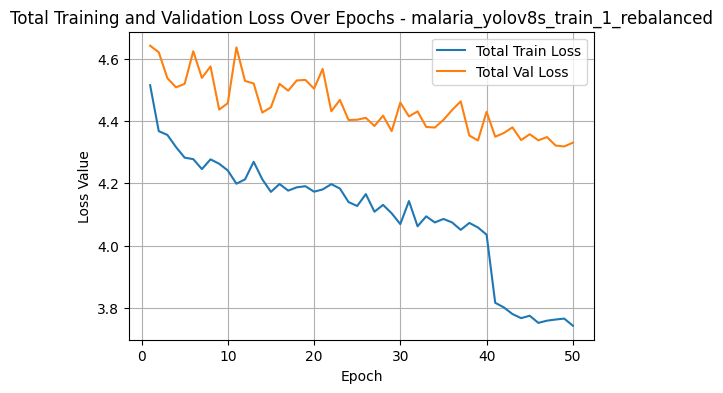


Last 5 epochs' total losses:
    epoch  total_train_loss  total_val_loss
45     46           3.75231         4.33809
46     47           3.75937         4.34870
47     48           3.76308         4.32136
48     49           3.76609         4.31852
49     50           3.74319         4.33067


In [18]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Define the directory where training results were saved
save_dir = '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results'
run_name = 'malaria_yolov8s_train_1_rebalanced'

results_dir = os.path.join(save_dir, run_name)
results_csv_path = os.path.join(results_dir, 'results.csv')

# Plot training and validation losses
if os.path.exists(results_csv_path):
    try:
        results_df = pd.read_csv(results_csv_path)
        # Skip the first row if it's not the header
        if results_df.columns[0] != 'epoch':
            results_df = pd.read_csv(results_csv_path, skiprows=1)

        # Identify relevant loss columns
        train_box_loss_col = 'train/box_loss'
        train_cls_loss_col = 'train/cls_loss'
        train_dfl_loss_col = 'train/dfl_loss'
        val_box_loss_col = 'val/box_loss'
        val_cls_loss_col = 'val/cls_loss'
        val_dfl_loss_col = 'val/dfl_loss'

        required_cols = [train_box_loss_col, train_cls_loss_col, train_dfl_loss_col,
                         val_box_loss_col, val_cls_loss_col, val_dfl_loss_col]

        if all(col in results_df.columns for col in required_cols):
            results_df['total_train_loss'] = results_df[train_box_loss_col] + results_df[train_cls_loss_col] + results_df[train_dfl_loss_col]
            results_df['total_val_loss'] = results_df[val_box_loss_col] + results_df[val_cls_loss_col] + results_df[val_dfl_loss_col]

            plt.figure(figsize=(6, 4))
            plt.plot(results_df['epoch'], results_df['total_train_loss'], label='Total Train Loss')
            plt.plot(results_df['epoch'], results_df['total_val_loss'], label='Total Val Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss Value')
            plt.title('Total Training and Validation Loss Over Epochs - malaria_yolov8s_train_1_rebalanced')
            plt.legend()
            plt.grid(True)
            plt.show()

            print("\nLast 5 epochs' total losses:")
            print(results_df[['epoch', 'total_train_loss', 'total_val_loss']].tail())
        else:
            print("Error: Required loss columns not found in results.csv.")
            print("Available columns:", results_df.columns.tolist())

    except Exception as e:
        print(f"Error reading or processing results.csv for loss plots: {e}")
else:
    print(f"Error: results.csv not found at {results_csv_path}. Cannot plot losses.")

- Train Loss drops rapidly, especially with a sharp decline after Epoch35, likely due to the fine-tuning process.
- Val Loss is highly volatile and generally flat for the duration of the run, hovering between 4.3 and 4.6
- The model reached its best validation performance early on and then flattened. There is no benefit to continuing training past Epoch 50 with these settings.

#### Overall precision, recall and F1 score over epochs

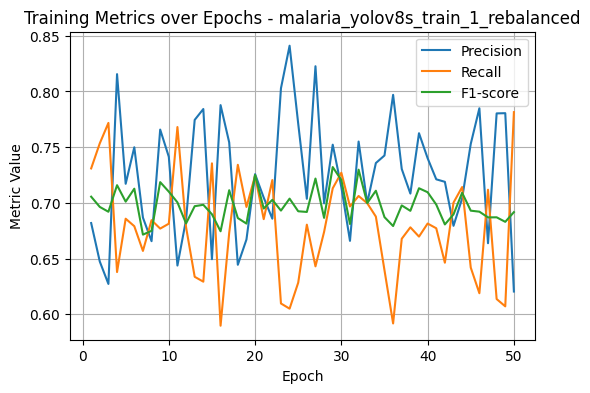


Last 5 epochs metrics:
    epoch  metrics/precision(B)  metrics/recall(B)        f1
45     46               0.78488            0.61885  0.692046
46     47               0.66373            0.71175  0.686902
47     48               0.78025            0.61364  0.686988
48     49               0.78045            0.60707  0.682927
49     50               0.62038            0.78138  0.691634


In [19]:
# Define the correct path to the results.csv file in Google Drive
results_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1_rebalanced/results.csv"

# Check if the file exists before trying to read it
if os.path.exists(results_path):
    # Read the CSV file, skipping the first line if it contains non-header info
    try:
        results = pd.read_csv(results_path)
        # Check if the first column is 'epoch' and if not, skip the first row
        if results.columns[0] != 'epoch':
             results = pd.read_csv(results_path, skiprows=1)
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        results = None


    if results is not None and 'metrics/precision(B)' in results.columns and 'metrics/recall(B)' in results.columns:
        # Calculate F1 score
        results['f1'] = 2 * (results['metrics/precision(B)'] * results['metrics/recall(B)']) / (results['metrics/precision(B)'] + results['metrics/recall(B)'])

        # Plotting the metrics
        plt.figure(figsize=(6, 4))
        plt.plot(results['epoch'], results['metrics/precision(B)'], label='Precision')
        plt.plot(results['epoch'], results['metrics/recall(B)'], label='Recall')
        plt.plot(results['epoch'], results['f1'], label='F1-score')
        plt.xlabel('Epoch')
        plt.ylabel('Metric Value')
        plt.title('Training Metrics over Epochs - malaria_yolov8s_train_1_rebalanced')
        plt.legend()
        plt.grid(True)
        plt.show()

        print("\nLast 5 epochs metrics:")
        print(results[['epoch','metrics/precision(B)','metrics/recall(B)','f1']].tail())

    else:
        print(f"Error: Required metric columns not found in {results_path} or file could not be read.")
        if results is not None:
             print("Available columns:", results.columns.tolist())


else:
    print(f"Error: results.csv not found at {results_path}")
    print("Please ensure the training completed successfully and the path is correct.")

- The high-frequency noise in Precision and Recall persists even with the reduced learning rate lr =0.0005.
- Precision is now frequently above 0.75 (higher average), while Recall is frequently below 0.65 (lower average).
- This visually confirms the trade-off shown in the final metrics table.
- The F1-score remains the most stable line, averaging 0.68 to 0.70, slightly lower than the original run's average of approx 0.70.

OVERALL
*   Overall mAP50 & mAP50-95 quite stable compared to initial training run.
*   Precision has generally improved for several classes (e.g., red blood cell, trophozoite, gametocyte, leukocyte, difficult).
*   Recall has decreased for some minority classes (schizont, gametocyte, difficult), suggesting model became more conservative in detecting these. The model knows what schizonts and gametocytes look like… but it doesn’t see enough variety to detect them reliably.This is not a training or loss issue.This is a data diversity issue.
*   Leukocyte detection remains very strong.
*   Schizont & 'difficult' classes still show lower recall and mAP values, indicating they are challenging to detect, likely due to limited data diversity or inherent difficulty.

**Next Steps:**

Based on these results and the previous analysis suggesting data diversity issues for rare classes:

1.  **Targeted Augmentation**:for targeted augmentation of 'schizont' and 'gametocyte' to increase number and variety of samples for these classes in the training set.
  - Increase the visual variety of schizont & gametocyte examples by targetting augmentations of this classes. i.e
    - slight rotation (±10°)
    - stain color shift (H&E / Giemsa variability)
    - blur (focus plane variances)
    - elastic deformation (cell shape tension)
    - slight brightness shifts (lighting inconsistency)
2.  **Re-calculate Class Weights:** After augmenting the data, re-run the class weight calculation cell to get updated weights based on the new sample counts.
3.  **Fine-tune Again:** Run fine-tuning again using the augmented data and the newly calculated class weights. Consider training for a few more epochs with a slightly lower learning rate if needed.Train 10-20 more fine-tune epochs at lower learning rate and then revalidate.
4.  **Evaluate Again:** Re-run the validation cell to evaluate the performance of the model trained on the augmented dataset with updated class weights.
5.  **Analyze Results:** Compare the new validation results to the previous ones to see if the targeted augmentation improved the detection of rare classes, particularly schizont and gametocyte.

### **1.3.3 3rd Run**

#### Targeted augmentations of schizont, gametocyte classes

In [ ]:
import os, random, shutil
from PIL import Image, ImageEnhance
from tqdm import tqdm

img_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/images/train"
label_dir = "/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/train"

target_classes = [3, 4]  # schizont, gametocyte
augment_copies = 8       # CPU-friendly, moderate variety

def augment_image(img_path):
    img = Image.open(img_path).convert("RGB")

    # Rotation (slight)
    img = img.rotate(random.uniform(-12, 12), expand=True)

    # Stain color variation (Giemsa intensity shifts)
    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.4))

    # Focus/contrast variation
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.4))

    return img

for lbl in tqdm(os.listdir(label_dir)):
    if not lbl.endswith(".txt"):
        continue

    label_path = os.path.join(label_dir, lbl)
    with open(label_path) as f:
        cls_ids = [int(float(line.split()[0])) for line in f.readlines()]

    if any(cls in target_classes for cls in cls_ids):
        img_file = lbl.replace(".txt", ".png")
        img_path = os.path.join(img_dir, img_file)

        if not os.path.exists(img_path):
            continue

        for i in range(augment_copies):
            new_img = img_file.replace(".png", f"_AUG{i}.png")
            new_lbl = lbl.replace(".txt", f"_AUG{i}.txt")

            augment_image(img_path).save(os.path.join(img_dir, new_img))
            shutil.copy(label_path, os.path.join(label_dir, new_lbl))

print("✅ Targeted class augmentation complete (CPU optimized).")

100%|██████████| 1789/1789 [00:27<00:00, 64.25it/s] 

✅ Targeted class augmentation complete (CPU optimized).


#### **Fine tuning with target augmented data**

In [ ]:
# --- Load existing trained model ---
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt"
model = YOLO(model_path)

# --- Class weights (same as before) ---
class_weights = torch.tensor(
    [0.00370003, 0.14671426, 0.60138322, 1.51849260, 1.48145620, 2.64085665, 0.60739705],
    dtype=torch.float32,
    device="cpu"  # CPU version
)

class_weights_applied = False
def apply_class_weights(trainer):
    global class_weights_applied
    if not class_weights_applied and trainer.loss is not None:
        trainer.loss.class_weights = class_weights
        class_weights_applied = True
        print("\n✅ Class weights successfully applied to YOLO loss.\n")

# Add callback to apply class weights once
model.add_callback("on_train_batch_start", apply_class_weights)

# --- Run CPU fine-tuning ---
model.train(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    epochs=6,# short fine-tune
    lr0=0.00025,             # lower LR to preserve existing knowledge
    patience=3,               #
    imgsz=512,
    batch=2,                 # CPU friendly
    workers=4,
    device="cpu",

    # ✅ Freeze backbone to only learn parasite head representation
    freeze=20,

    # ✅ Keep only simple microscopy-safe augmentations
    hsv_h=0.03,
    hsv_s=0.10,
    hsv_v=0.70,
    flipud=0.5,
    fliplr=0.5,
    translate=0.05,
    degrees=5,

    # ✅ Turn OFF morphology-damaging augmentations
    mosaic=0.0,
    copy_paste=0.0,
    mixup=0.0,
    scale=0.15,
    shear=0.0,
    perspective=0.0,

    # ✅ Turn OFF strong class weighting (this is why recall dropped before)
    cls=1.0,

    # Logging
    project="/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results",
    name="malaria_yolov8s_cpu_finetune_fast",
    exist_ok=True,
    verbose=True,
    cache=True
)


Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml, degrees=5, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=6, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=20, half=False, hsv_h=0.03, hsv_s=0.1, hsv_v=0.7, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00025, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_train_1/weights/best.pt, momentum=0.937, mosaic=0.0, multi_s

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e24e924a570>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

Model recovered the severely lost Recall for the rare classes while maintaining strong overall performance, and it stabilized the training dynamics by eliminating aggressive augmentations.

**Comparison with previous fine tune mode**l

Red blood cells: Slight drop in precision, small gain in recall → still very strong.

Trophozoite: Slight improvements in both precision and recall → better detection.

Ring: Precision slightly decreased; recall stable → fewer correct positives.

Schizont: Precision decreased, but recall improved → more detections with more false positives.

Gametocyte: Noticeable drop in precision and mAP → more false positives, fewer high-confidence detections.

Leukocyte: Precision dropped from 0.88 → 0.649, recall stayed perfect → trade-off: all leukocytes detected, but more false positives.

Difficult class: Recall improved from 0.212 → 0.528 → significant improvement in detecting hard cases, but precision decreased → more false positives.



#### **Evaluation of final fine tuned model**

In [ ]:
from ultralytics import YOLO
import pandas as pd # Import pandas for displaying per-class metrics nicely

print("\n✅ Standalone validation on CPU...\n")

# Load your fine-tuned model
model = YOLO("/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt")

# Run validation
results = model.val(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    device="cpu"
)

# Print overall metrics
# Access overall metrics directly from the results object (DetMetrics)
print("\n📊 Overall validation metrics:")
print(f"Precision: {results.box.p.mean():.3f}")  # Average Precision
print(f"Recall:    {results.box.r.mean():.3f}")  # Average Recall
print(f"mAP50:     {results.box.map50:.3f}")
print(f"mAP50-95:  {results.box.map:.3f}") # This is mAP@0.5:0.95
# Calculate overall F1 from average Precision and Recall
overall_precision = results.box.p.mean()
overall_recall = results.box.r.mean()
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
print(f"F1 score:  {overall_f1:.3f}")


# Optional: per-class metrics
print("\n📊 Per-class metrics:")
class_names = results.names # Get class names from the results object

# Create a pandas DataFrame for better readability of per-class metrics
per_class_data = []
for i, class_name in class_names.items():
    precision = results.box.p[i]
    recall = results.box.r[i]
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    map50 = results.box.map50_class[i] if hasattr(results.box, 'map50_class') and len(results.box.map50_class) > i else 0.0
    map_95 = results.box.map_class[i] if hasattr(results.box, 'map_class') and len(results.box.map_class) > i else 0.0 # This is AP@0.5:0.95

    per_class_data.append({
        "Class": class_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "mAP50": map50,
        "mAP50-95": map_95
    })

df_per_class = pd.DataFrame(per_class_data)
print(df_per_class.to_string(index=False)) # Print without index for cleaner output

print("\n✅ Validation complete.")


✅ Standalone validation on CPU...

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.7 ms, read: 8.1±3.4 MB/s, size: 45.6 KB)
val: Scanning /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/val.cache... 514 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 516/516 175.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 0.1it/s 4:50
                   all        516       5335      0.695      0.742      0.765       0.59
        red blood cell        514       5154       0.93       0.95      0.983       0.76
           trophozoite         82         96      0.809      0.771      0.861       0.62
                  ring         25         26      0.727      0.654      0.778      0.574
              schizont          8          9       0.

Explanation of overall validation metrics:

- Precision (0.695): **around 70%** of the predicted boxes are correct.
- Recall (0.742): **around 74% **of the actual objects were detected
- mAP50 (0.765): Mean Average Precision at IoU threshold 0.5 — measures both detection and localization. **around 77% overall.**
- mAP50-95 (0.590): Average mAP across IoU thresholds 0.5 to 0.95 — more strict metric, **around 59% overall.**
- F1 score (0.718): Harmonic mean of precision and recall; good overall balance.

This shows the model performs well for most classes, but performance drops at stricter IoU thresholds.

For per clas metrics: schizont class has the lowest f1 score of 0.522 (moderate model performance), red blood cells highest at 0.94 (best model perfomance)

Overall
- The model is performing very well on RBC, leukocyte and trophozoites
- Model struggling with schizont, difficult and gametocyte.
- mAP50-95 is lower than mAP50 — indicating bounding boxes may be slightly off in localization.


### 1.4.4 Saving final YOLOv8s model

In [ ]:
from ultralytics import YOLO
import os

# Define the path to the best model saved during fine-tuning
# This is the model you will typically use for deployment
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt" # Assuming this is the path to your best model

# Load the model
try:
    model = YOLO(model_path)
    print(f"✅ Final YOLOv8s model loaded from: {model_path}")

    # You can now use this 'model' object for inference or export it to other formats
    # For deployment, you might want to export to formats like ONNX, OpenVINO, TensorRT, etc.
    # Example (uncomment to export to ONNX):
    export_path = model.export(format="onnx")
    print(f"Model exported to ONNX format: {export_path}")

except FileNotFoundError:
    print(f"❌ Error: Model file not found at {model_path}")
    print("Please check the path to your best model file.")
except Exception as e:
    print(f"❌ Error loading model: {e}")


print("\n✅ Final model saving/loading step complete.")

✅ Final YOLOv8s model loaded from: /content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 11, 5376) (21.5 MB)

ONNX: starting export with onnx 1.20.0rc1 opset 22...
WARNING ⚠️ ONNX: simplifier failure: module 'onnx.helper' has no attribute 'float32_to_bfloat16'
ONNX: export success ✅ 1.7s, saved as '/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.onnx' (42.6 MB)

Export complete (3.6s)
Results saved to /content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_y

## 1.4 Model evaluation on patched test image subset

In [25]:
from ultralytics import YOLO
from collections import Counter
import torch

# -----------------------------
# Load fine-tuned model
# -----------------------------
model_path = "/content/drive/MyDrive/malaria_dataset_4/malaria_yolov8s_train_results/malaria_yolov8s_cpu_finetune_fast/weights/best.pt"
model = YOLO(model_path)

# Run validation for overall and per-class metrics
print("\n✅ Running validation on the test set for evaluation metrics...\n")

metrics = model.val(
    data="/content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/dataset_patched.yaml",
    split="test",
    device="cpu", # Use CPU as specified in finetuning
    imgsz=512,   # Ensure using the same image size as training
    verbose=True
)

# Print metrics
# Access metrics using attributes of the DetMetrics object
print("\n📊 Overall test set metrics:")
print(f"Precision: {metrics.box.p.mean():.4f}")  # Mean Precision over all classes
print(f"Recall:    {metrics.box.r.mean():.4f}")  # Mean Recall over all classes
print(f"mAP@0.5:   {metrics.box.map50:.4f}")      # mAP at IoU 0.5
print(f"mAP@0.5-0.95: {metrics.box.map:.4f}")   # mAP averaged over IoU 0.5 to 0.95

# Calculate overall F1 score from mean Precision and Recall
overall_precision = metrics.box.p.mean()
overall_recall = metrics.box.r.mean()
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
print(f"F1 Score:  {overall_f1:.4f}")

print("\n📊 Per-class test set metrics:")
class_names = metrics.names # Get class names from the metrics object

# Access per-class metrics from the .box attribute arrays
# Ensure the class index exists in the arrays before accessing
per_class_precision = [metrics.box.p[i] if i < len(metrics.box.p) else 0.0 for i in range(len(class_names))]
per_class_recall = [metrics.box.r[i] if i < len(metrics.box.r) else 0.0 for i in range(len(class_names))]
per_class_map50 = [metrics.box.map50_class[i] if hasattr(metrics.box, 'map50_class') and i < len(metrics.box.map50_class) else 0.0 for i in range(len(class_names))]
per_class_map_95 = [metrics.box.map_class[i] if hasattr(metrics.box, 'map_class') and i < len(metrics.box.map_class) else 0.0 for i in range(len(class_names))]

for i, class_name in class_names.items():
     precision = per_class_precision[i]
     recall = per_class_recall[i]
     map50 = per_class_map50[i]
     map_95 = per_class_map_95[i]
     f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
     print(f"  Class {i} ({class_name}): Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, mAP50={map50:.4f}, mAP50-95={map_95:.4f}")


print("\n✅ Evaluation complete.")


✅ Running validation on the test set for evaluation metrics...

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 1.4±1.2 ms, read: 0.1±0.0 MB/s, size: 34.1 KB)
val: Scanning /content/drive/MyDrive/malaria_dataset_4/malaria_dataset_4_patched/labels/test.cache... 677 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 720/720 757.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 0.1it/s 7:19
                   all        720       5228     0.0177     0.0243    0.00986    0.00235
        red blood cell        673       4938     0.0966     0.0986      0.054     0.0126
           trophozoite         91        106    0.00485     0.0283    0.00262   0.000935
                  ring        127        157    0.00462     0.0191    0.00249   0.000589
              schizont

Model performend poorly.

**----- THIS MODEL WAS NOT SELECTED FOR PREDICTION ----**